In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from intervalinf import IntervalDomain, Lebesgue, Function, BoundaryConditions, IntegrationConfig
from intervalinf.operators import SOLAOperator, Laplacian, BesselSobolevInverse
from intervalinf.providers import BoxCarFunctionProvider, FourierFunctionProvider, CosineFunctionProvider
from intervalinf.sampling import KLSampler

from pygeoinf import EuclideanSpace, ColumnLinearOperator, HilbertSpaceDirectSum, GaussianMeasure, LinearForwardProblem, LinearBayesianInference, CholeskySolver

In [2]:
# Create the latent model space
function_domain = IntervalDomain(0, 1, boundary_type="closed")
integration_confidg = IntegrationConfig(
    method='simpson',
    n_points=8192
)
M = Lebesgue(0, function_domain, integration_config=integration_confidg)

In [3]:
# Create the two analysis maps

N_1 = 10 # number of pixel functions
pixel_width = function_domain.length / N_1
pixel_centers = [
    function_domain.a + (i + 0.5) * pixel_width for i in range(N_1)
]
pixel_function_provider = BoxCarFunctionProvider(function_domain, default_width=pixel_width,
                                                 centers=pixel_centers, normalize=False,
                                                 default_height=1/(np.sqrt(pixel_width)))
M_1 = EuclideanSpace(N_1)
Pi_1 = SOLAOperator(M, M_1, kernels=pixel_function_provider, integration_config=integration_confidg)


N_2 = 20 # number of fourier functions
fourier_function_provider = FourierFunctionProvider(function_domain)
M_2 = EuclideanSpace(N_2)
Pi_2 = SOLAOperator(M, M_2, kernels=fourier_function_provider, integration_config=integration_confidg)

In [4]:
# Combine the two data spaces into one and the two analysis maps into one
D = HilbertSpaceDirectSum([M_1, M_2])
Pi = ColumnLinearOperator([Pi_1, Pi_2])

# And crate the property mapping and property space
N_p = 20
target_width = function_domain.length / N_p
target_centers = [
    function_domain.a + (i + 0.5) * target_width for i in range(N_p)
]
target_function_provider = BoxCarFunctionProvider(function_domain, default_width=0.05 * function_domain.length, centers=target_centers)
P = EuclideanSpace(N_p)

T = SOLAOperator(M, P, kernels=target_function_provider, integration_config=integration_confidg)

<Axes: title={'center': 'Function on [0.0, 1.0]'}, xlabel='x', ylabel='f(x)'>

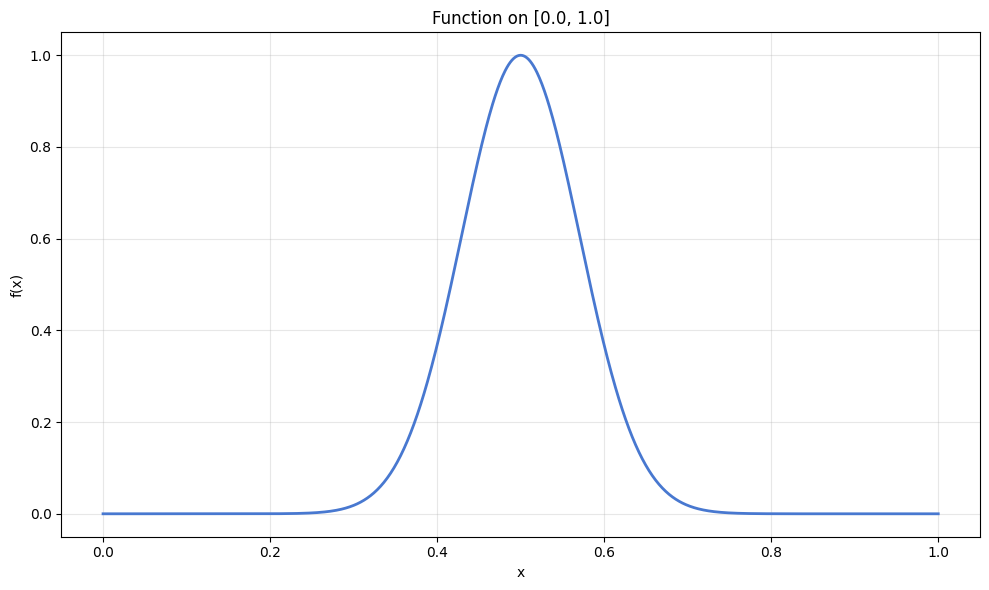

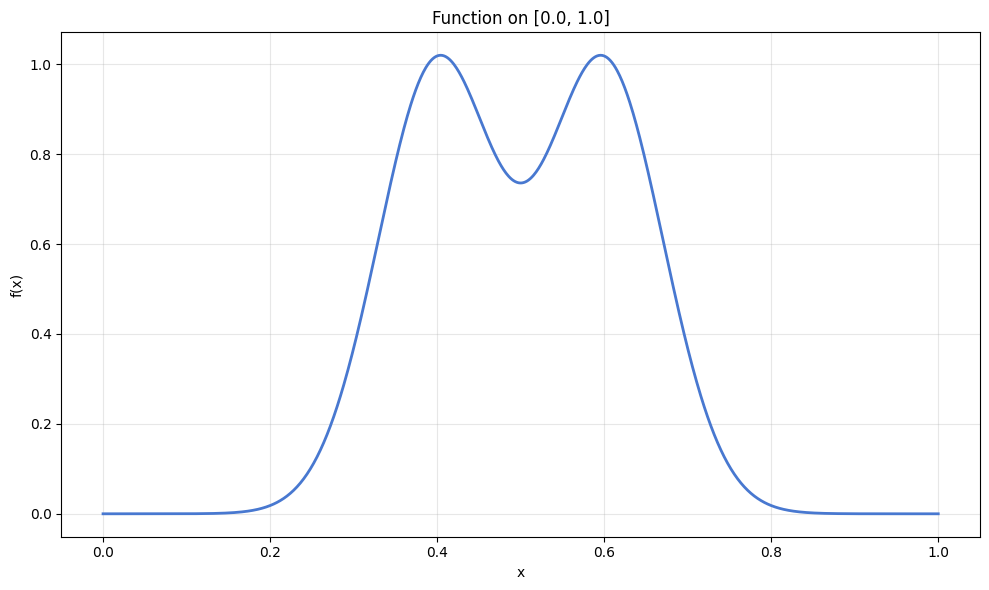

In [5]:
# Create a true model in M
# Lambda must be vectorized to handle numpy arrays - use np.where for conditionals
m_true = Function(M, evaluate_callable=lambda x: np.exp(-100 * (x - 0.5) ** 2))
m_true.plot()

m_true_2 = Function(M, evaluate_callable=lambda x: np.exp(-100 * (x - 0.4) ** 2)) + Function(M, evaluate_callable=lambda x: np.exp(-100 * (x - 0.6) ** 2))
m_true_2.plot()

Data without noise: [array([4.34491287e-09, 6.19284306e-06, 1.30732911e-03, 4.27600205e-02,
       2.36240359e-01, 2.36064316e-01, 4.28097334e-02, 1.30495387e-03,
       6.20877394e-06, 4.33037430e-09]), array([ 3.54490767e-01, -3.67463690e-01,  2.11292230e-17,  1.04387787e-01,
        1.45028124e-17,  6.37285362e-02, -1.98792896e-17, -8.36117351e-02,
        2.90051616e-17,  4.25149050e-02, -4.35412621e-17, -1.16146036e-02,
        1.57510090e-17,  1.22972216e-03, -1.86321348e-17,  2.79805620e-04,
       -9.73979097e-19, -1.36826781e-04,  9.74482021e-18,  2.59276778e-05])]


<Axes: title={'center': 'Function on [0.0, 1.0]'}, xlabel='x', ylabel='f(x)'>

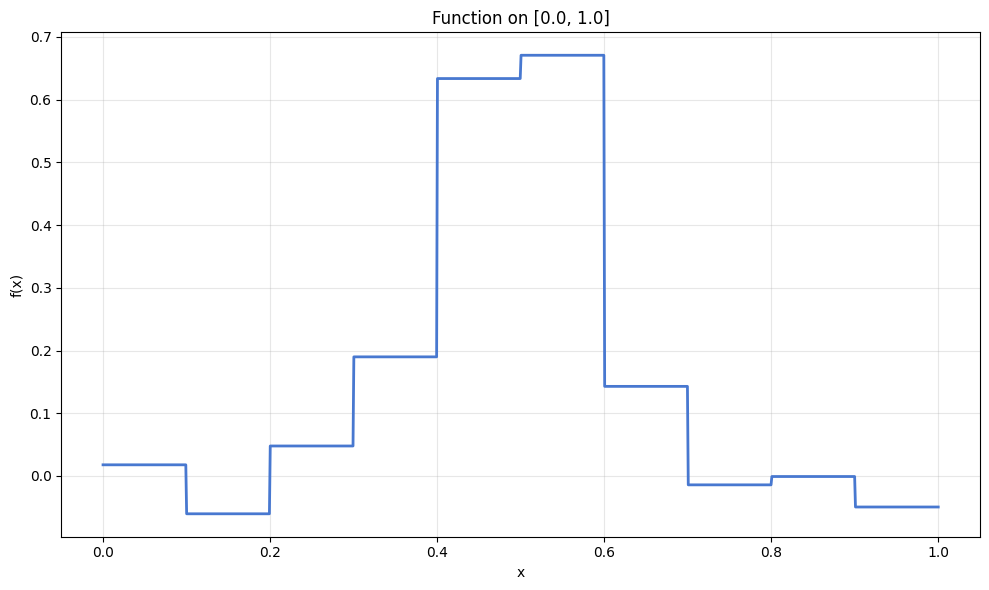

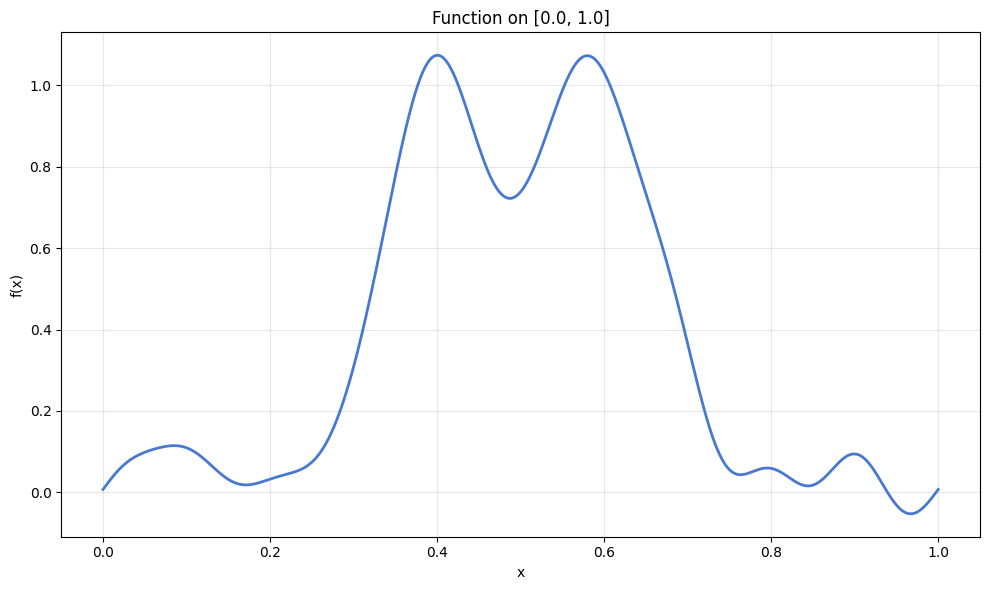

In [6]:
# Compute the data (joint)
#d = Pi(m_true)
d_1 = Pi_1(m_true)
d_2 = Pi_2(m_true_2)
d = [d_1, d_2]
print("Data without noise:", d)

#and add noise
noise = 0.05 * max(np.max(np.abs(x)) for x in d)
rng = np.random.default_rng(42)
d_noisy = [x + rng.normal(scale=noise, size=x.shape) for x in d]

# And reconstruct the models
m_1_reconstructed = Pi_1.adjoint(d_noisy[0])
m_2_reconstructed = Pi_2.adjoint(d_noisy[1])
m_1_reconstructed.plot()  # Warm-up
m_2_reconstructed.plot()  # Warm-up

In [7]:
# generate uncertainties on M_1 and M_2 and combine them to form the uncertainty in D
noise_variance_M_1 = noise ** 2
C_M_1_matrix = noise_variance_M_1 * np.eye(N_1)
C_M_1_matrix[0,0] *= 10
gaussian_noise_measure_M_1 = GaussianMeasure.from_covariance_matrix(M_1, C_M_1_matrix, expectation=M_1.zero)
noise_variance_M_2 = noise ** 2
C_M_2_matrix = noise_variance_M_2 * np.eye(N_2)
gaussian_noise_measure_M_2 = GaussianMeasure.from_covariance_matrix(M_2, C_M_2_matrix, expectation=M_2.zero)

gaussian_noise_measure = GaussianMeasure.from_direct_sum([gaussian_noise_measure_M_1, gaussian_noise_measure_M_2])

In [8]:
# Now generate prior gaussian on laten models space M
# Define prior measure parameters
bcs = BoundaryConditions(bc_type='neumann', left=0, right=0)

# Create Laplacian operator using the configured integration settings
s = 6
length_scale = 0.2
overall_variance = 0.1
k = np.power(overall_variance, -0.5/s)
alpha = (length_scale**2) * k**2
L = Laplacian(M, bcs, alpha, method='spectral', dofs=100, integration_config=integration_confidg)
C_0 = BesselSobolevInverse(M, M, k, s, L, dofs=30, n_samples=4096, integration_config=integration_confidg)
# Prior mean (simple linear trend)
m_0 = Function(M, evaluate_callable=lambda x: np.zeros_like(x))

# Set up Karhunen-Loève expansion for efficient sampling
K = 100  # Number of KL terms (should be ≥ N for full representation)
sampler = KLSampler(C_0, mean=m_0, n_modes=K)
M_prior = GaussianMeasure(covariance = C_0, expectation=m_0, sample=sampler.sample)


In [9]:
A = (Pi @ C_0 @ Pi.adjoint).matrix(dense=True, galerkin=True, parallel=True, n_jobs=12)

sym_diff = np.linalg.norm(A - A.T, ord=np.inf)
is_symmetric = np.allclose(A, A.T, atol=1e-8, rtol=1e-5)
print("symmetry ||A-A^T||_inf =", sym_diff, "symmetric?", is_symmetric)

# symmetrize to avoid tiny numerical asymmetry
B = A

# try Cholesky (fast and definitive for SPD)
try:
    np.linalg.cholesky(B)
    print("Matrix is symmetric positive-definite (Cholesky succeeded).")
except np.linalg.LinAlgError:
    # fallback: inspect smallest eigenvalue for near-PSD
    w = np.linalg.eigvalsh(B)
    min_eig = w.min()
    # relative tolerance: treat extremely tiny negatives as numerical noise
    tol = 1e-12 * max(1.0, np.max(np.abs(w)))
    print("Cholesky failed; min eigenvalue =", min_eig, "tol =", tol)
    if min_eig > tol:
        print("Matrix is (numerically) positive-definite.")
    elif min_eig > -10*tol:
        print("Matrix is nearly positive-semidefinite (tiny negative eigenvalue).")
    else:
        print("Matrix is not positive-definite (significant negative eigenvalue).")

symmetry ||A-A^T||_inf = 0.0011721373236691572 symmetric? False
Cholesky failed; min eigenvalue = -0.00020535646455681323 tol = 1e-12
Matrix is not positive-definite (significant negative eigenvalue).


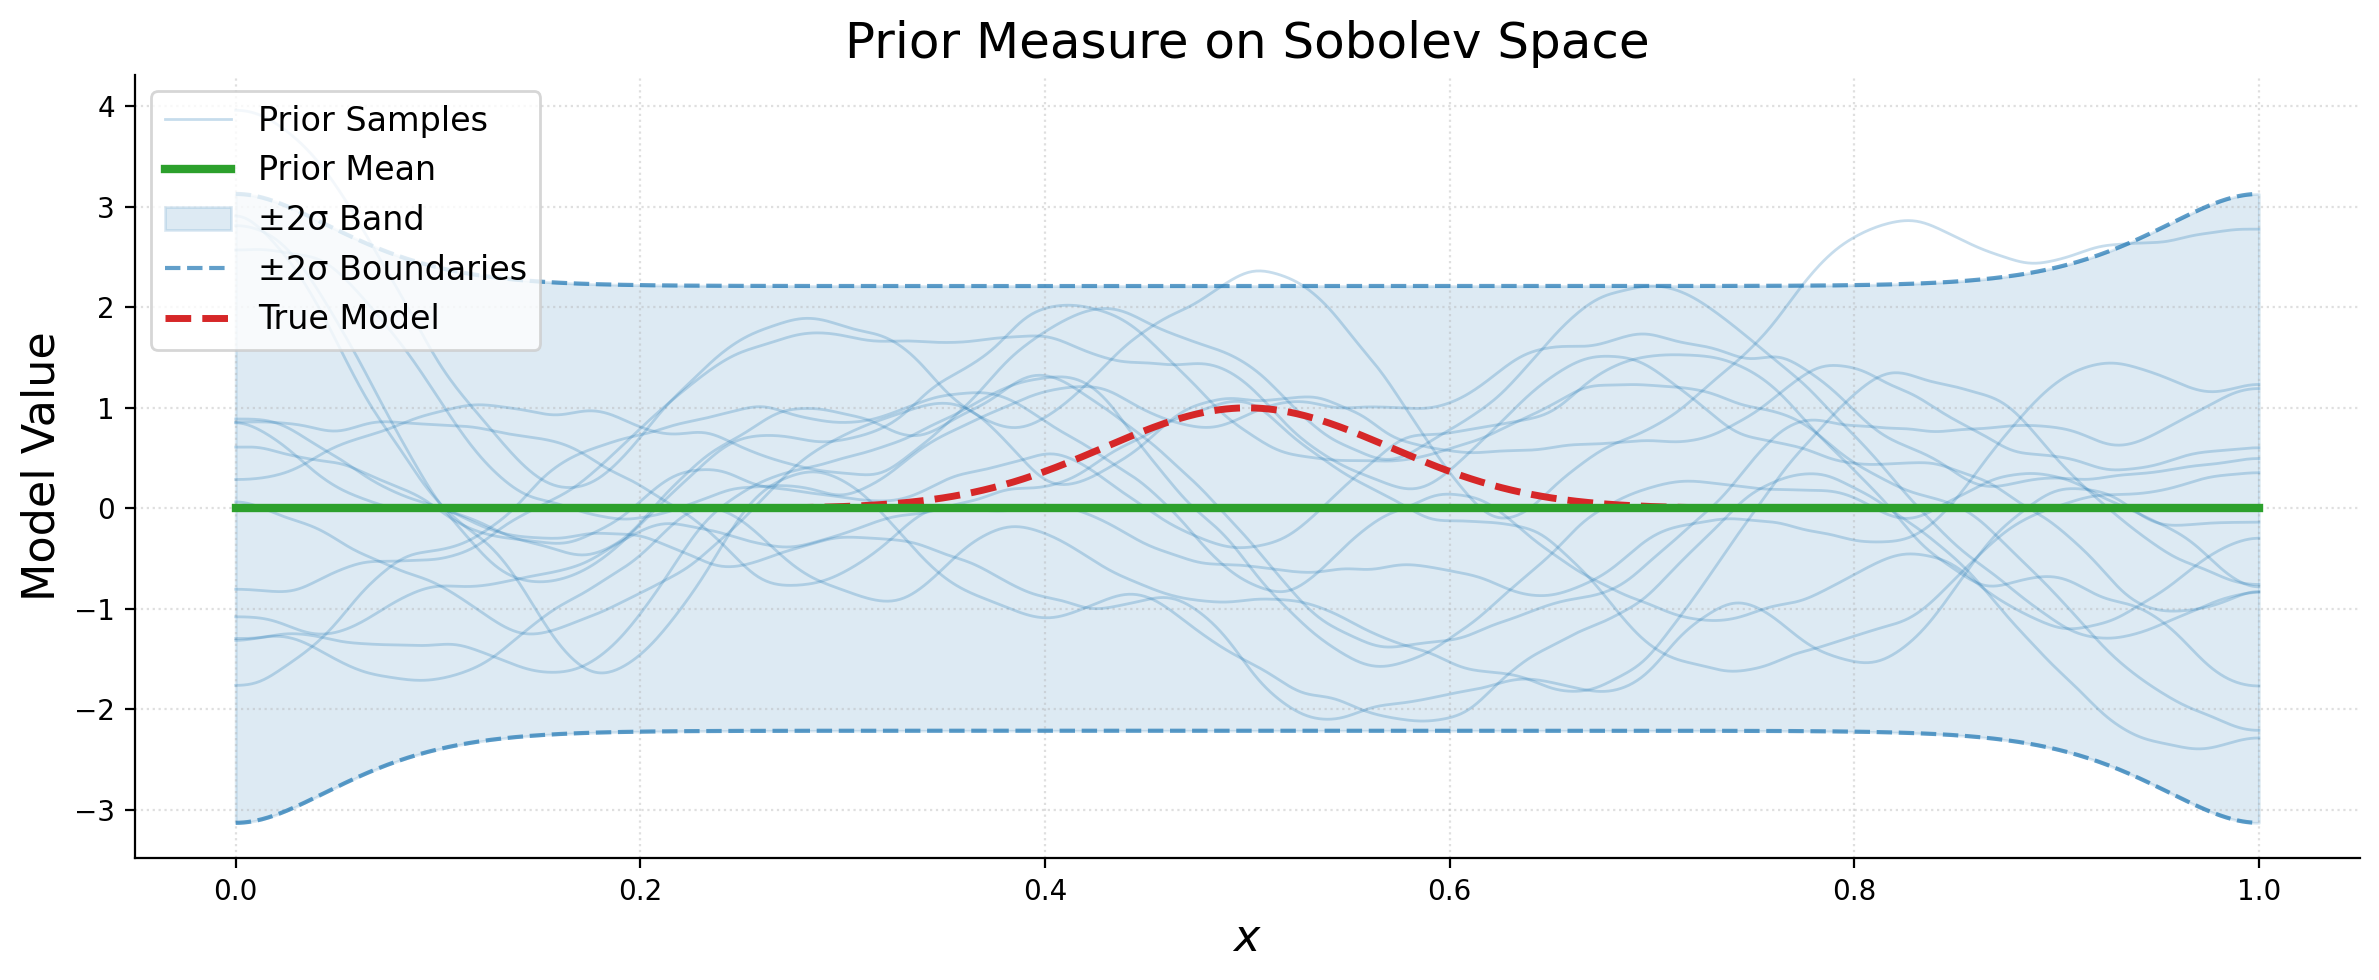

In [10]:
# Visualize the prior measure
fig_title = "Prior Measure on Model Space (Sobolev)"
# Parameters for visualization
num_samples = 15
sample_color = 'tab:blue'
mean_color = 'tab:green'
std_color = 'tab:blue'

plt.figure(figsize=(12, 5), dpi=200)

# Plot prior samples
x = function_domain.uniform_mesh(1000)
for i in range(num_samples):
    sample = M_prior.sample()
    plt.plot(x, sample.evaluate(x), color=sample_color, alpha=0.25, linewidth=1,
            label='Prior Samples' if i == 0 else "")

# Compute and plot uncertainty bounds
# Use KLSampler's variance_function for cleaner computation
variance_func = sampler.variance_function()
std_values = np.sqrt(variance_func.evaluate(x))

# Plot prior mean and uncertainty
mean_values = M_prior.expectation.evaluate(x)
plt.plot(x, mean_values, color=mean_color, linewidth=3, label='Prior Mean', zorder=10)
plt.fill_between(x, mean_values - 2*std_values, mean_values + 2*std_values,
                 color=std_color, alpha=0.15, label='±2σ Band')
plt.plot(x, mean_values + 2*std_values, color=std_color, linestyle='--',
        alpha=0.7, linewidth=1.5, label='±2σ Boundaries')
plt.plot(x, mean_values - 2*std_values, color=std_color, linestyle='--',
        alpha=0.7, linewidth=1.5)

# Plot true model
plt.plot(x, m_true.evaluate(x), color='tab:red', linewidth=2.5,
        label='True Model', linestyle='--', zorder=9)

plt.title("Prior Measure on Sobolev Space", fontsize=18)
plt.xlabel(r"$x$", fontsize=16)
plt.ylabel("Model Value", fontsize=16)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

In [11]:
# Now we have the latent model space M, the prior on the latent model space,
# the data space which is just the direct sum of M_1 and M_2, the forward
# operator Pi from M to D, the noisy data d_noisy in D (discretized models
# basically), and the property space and the property mapping T from M to P. We
# will now use p[ygeoinf to set up and then solve this inference problem.

forward_problem = LinearForwardProblem(Pi, data_error_measure = gaussian_noise_measure)
bayesian_inference = LinearBayesianInference(forward_problem, M_prior, T)
solver = CholeskySolver(parallel=True, n_jobs=16)

property_posterior = bayesian_inference.property_posterior_measure(d_noisy, solver)
p_tilde = property_posterior.expectation
cov_P_matrix = property_posterior.covariance.matrix(
        dense=True,
        galerkin=True,
        parallel=True,
        n_jobs=16
    )

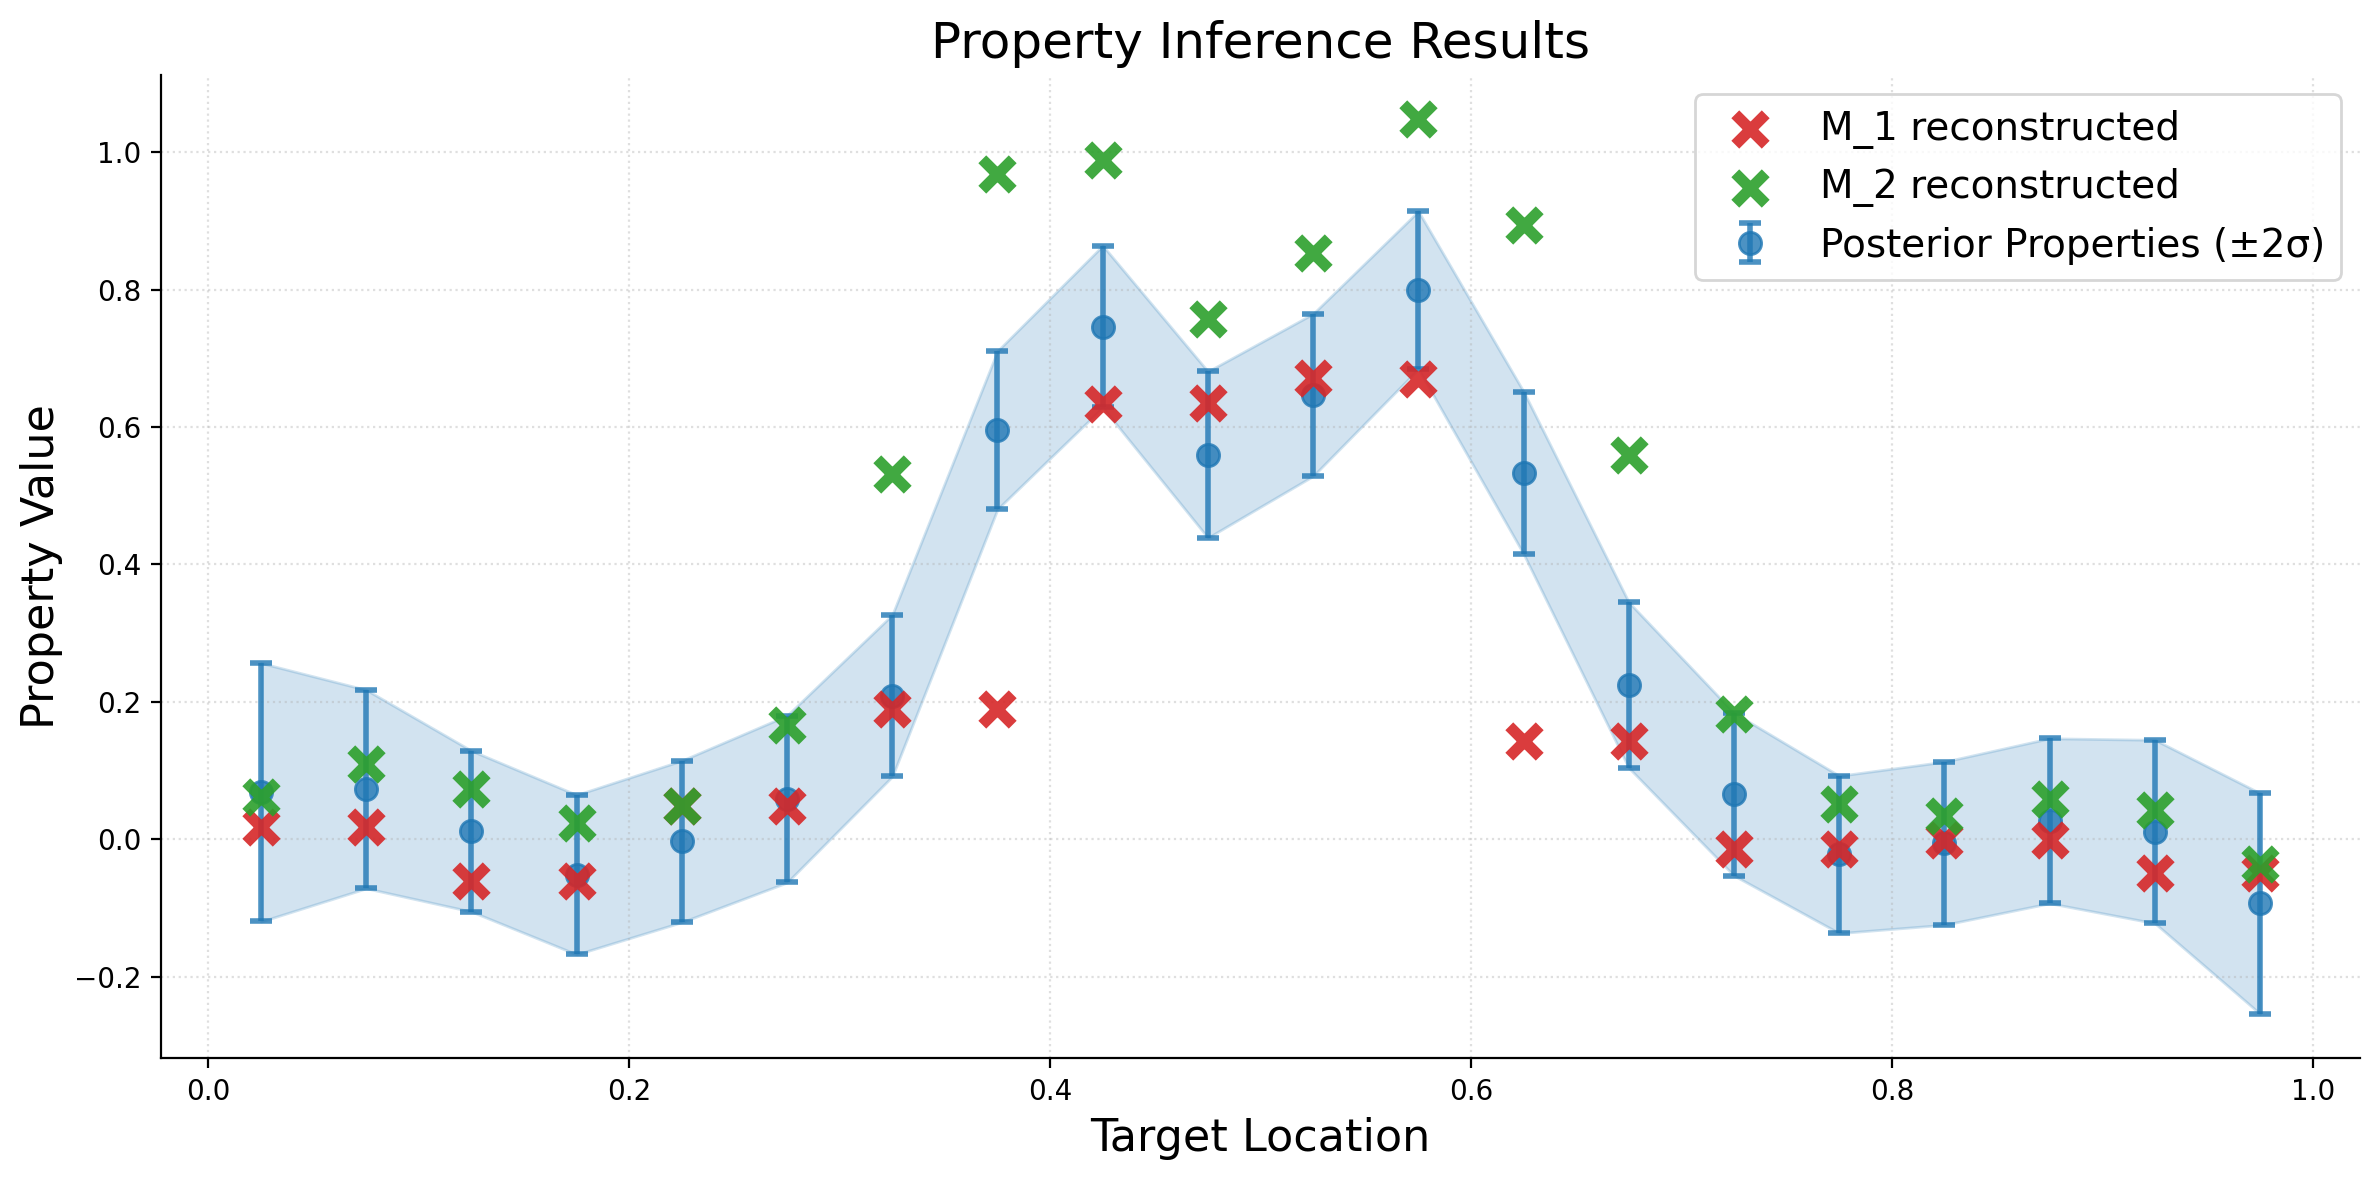

In [12]:
# Final property inference results
std_P_post = np.sqrt(np.diag(cov_P_matrix))

plt.figure(figsize=(12, 6), dpi=200)

# Property posterior with uncertainty
plt.errorbar(target_centers, p_tilde, yerr=2*std_P_post, fmt='o', color='tab:blue',
            alpha=0.8, capsize=4, capthick=2, markersize=8, linewidth=2,
            label='Posterior Properties (±2σ)')
plt.fill_between(target_centers, p_tilde - 2*std_P_post, p_tilde + 2*std_P_post,
                color='tab:blue', alpha=0.2)

# True properties
m_1_reconstructed_props = T(m_1_reconstructed)
m_2_reconstructed_props = T(m_2_reconstructed)
plt.scatter(target_centers, m_1_reconstructed_props, label='M_1 reconstructed',
           color='tab:red', marker='x', s=120, alpha=0.9, linewidths=4, zorder=10)
plt.scatter(target_centers, m_2_reconstructed_props, label='M_2 reconstructed',
           color='tab:green', marker='x', s=120, alpha=0.9, linewidths=4, zorder=10)
#true_props = T(m_true) --- IGNORE ---

plt.xlabel('Target Location', fontsize=16)
plt.ylabel('Property Value', fontsize=16)
plt.title(f'Property Inference Results', fontsize=18)
plt.legend(fontsize=14, loc='best')
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()
